# ==============================
# E-Commerce Sales Analysis Project
# =============================

# ================
# import Libraries
# ================

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


#Load Data

In [11]:
df = pd.read_csv("C:\\Users\\Dell\\OneDrive\\Desktop\\My Project\\Ecommerce_Sales_Analysis\\Data\\Clean_Data.csv", encoding= 'latin')
print(df.head())

   Row ID.1        Order ID  Order Date   Ship Date       Ship Mode  \
0         1  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
1         2  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
2         3  CA-2017-138688  12-06-2017  16-06-2017    Second Class   
3         4  US-2016-108966  11-10-2016  18-10-2016  Standard Class   
4         5  US-2016-108966  11-10-2016  18-10-2016  Standard Class   

  Customer ID    Customer Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4    SO-20335   Sean O'Donnell   Consumer  United States  Fort Lauderdale   

        State  Postal Code Region       Product ID         Category  \
0    Kentucky      42420.0  South  FUR-

# ===========
# Total Sales
# ===========

In [12]:
total_sales = df['Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827


# ============
# Total Orders
# ============

In [13]:
total_orders = df['Order ID'].nunique()
print("Total Orders:", total_orders)

Total Orders: 4922


# ===============
# Total customers
# ===============

In [14]:
total_customers = df['Customer Name'].nunique()
print("Total Customers:",total_customers)

Total Customers: 793


# ===============
# Sales by Region
# ===============

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


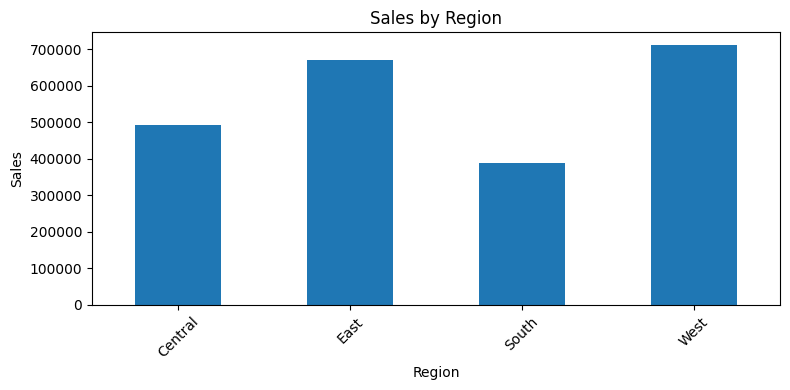

In [15]:
sales_region = df.groupby('Region')['Sales'].sum()
print(sales_region)

plt.figure(figsize= (8,4))
sales_region.plot(kind = 'bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("chart/sales_by_region.png")
plt.show()

# ===============
# Top 5 Customers
# ===============

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


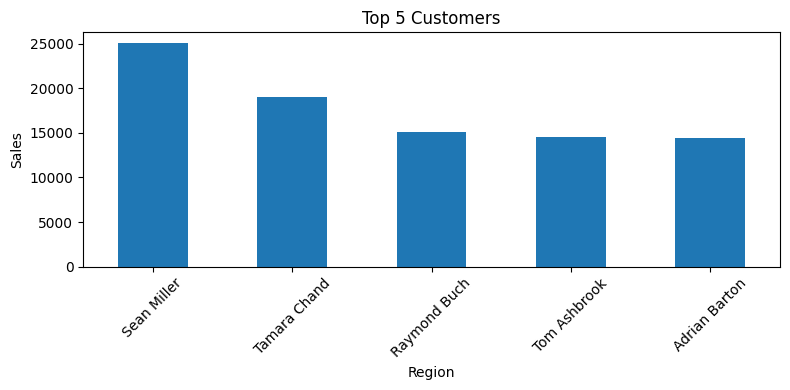

In [16]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending = False).head(5)
print(top_customers)

plt.figure(figsize= (8,4))
top_customers.plot(kind = 'bar')
plt.title("Top 5 Customers")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("chart/top_customers.png")
plt.show()

# ======================
# Sales By Sub-Category
# ======================

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


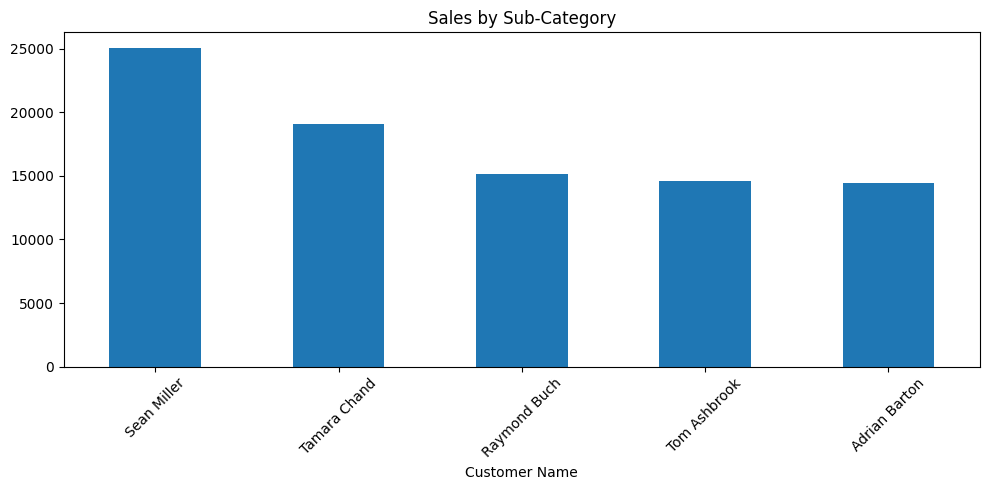

In [17]:
subcat = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending = False)
print(subcat)

plt.figure(figsize= (10,5))
top_customers.plot(kind = 'bar')
plt.title("Sales by Sub-Category")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.savefig("chart/sub-category.png")
plt.show()

# ============
# Monthly Sales
# ============

Month
April        136283.0006
August       157315.9270
December     321480.1695
February      59371.1154
January       94291.6296
July         145535.6890
June         145837.5233
March        197573.5872
May          154086.7237
November     350161.7110
October      199496.2947
September    300103.4117
Name: Sales, dtype: float64


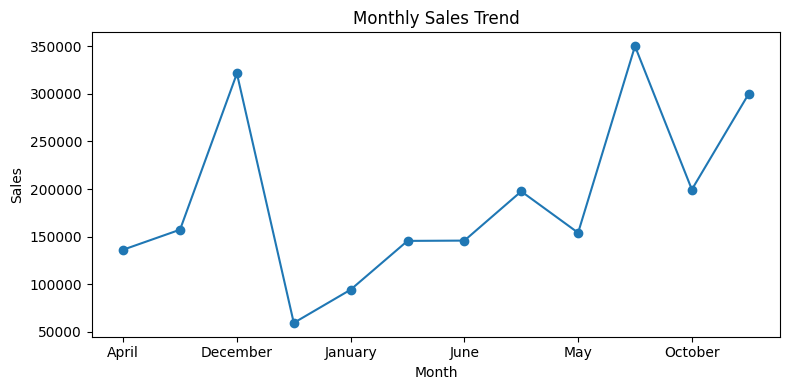

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True, errors = 'coerce')
df['Month'] = df['Order Date'].dt.month_name()
monthly = df.groupby('Month')['Sales'].sum()    
print(monthly)

plt.figure(figsize= (8,4))
monthly.plot(kind = 'line', marker = 'o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("chart/monthly_sales.png")
plt.show()